In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [66]:
df = pd.read_csv("dataset.csv")

In [67]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [70]:
print(df.shape)

(114000, 21)


In [73]:
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [77]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [79]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

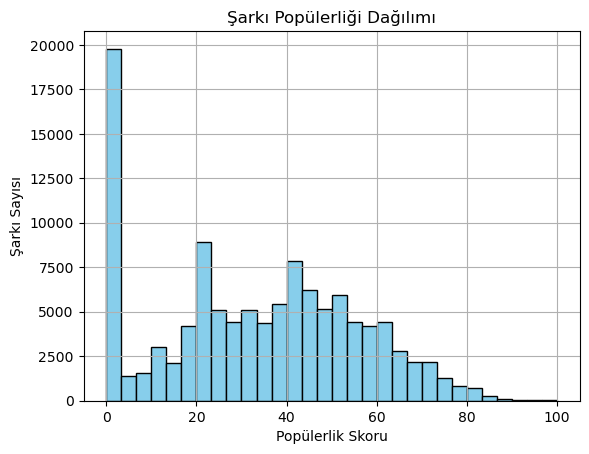

In [81]:
df['popularity'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Şarkı Popülerliği Dağılımı')
plt.xlabel('Popülerlik Skoru')
plt.ylabel('Şarkı Sayısı')
plt.grid(True)
plt.show()

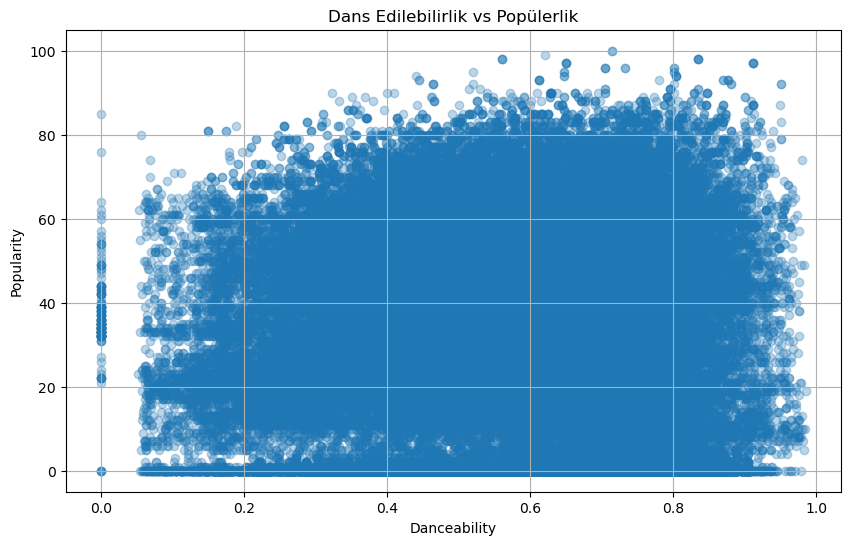

In [83]:
plt.figure(figsize=(10, 6))
plt.scatter(df['danceability'], df['popularity'], alpha=0.3)
plt.title('Dans Edilebilirlik vs Popülerlik')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.grid(True)
plt.show()

In [84]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [87]:
df['popularity'] = df['popularity'].fillna(df['popularity'].mean())

In [89]:
df[['popularity', 'danceability']].describe()

,popularity,danceability
count,114000.000000,114000.000000
mean,33.238535,0.566800
std,22.305078,0.173542
min,0.000000,0.000000
25%,17.000000,0.456000
50%,35.000000,0.580000
75%,50.000000,0.695000
max,100.000000,0.985000


In [91]:
df = df.dropna()

In [93]:
df = df.drop(['Unnamed: 0', 'track_id', 'album_name', 'track_name'], axis=1)


In [95]:
df = df.dropna()

In [97]:
print("Danceability:", df['danceability'].min(), "-", df['danceability'].max())
print("Popularity:", df['popularity'].min(), "-", df['popularity'].max())

Danceability: 0.0 - 0.985
Popularity: 0 - 100


In [99]:
df = df[(df['danceability'] >= 0) & (df['danceability'] <= 1)]
df = df[(df['popularity'] >= 0) & (df['popularity'] <= 100)]

In [101]:
df = df.drop_duplicates()

C:\Users\T7\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


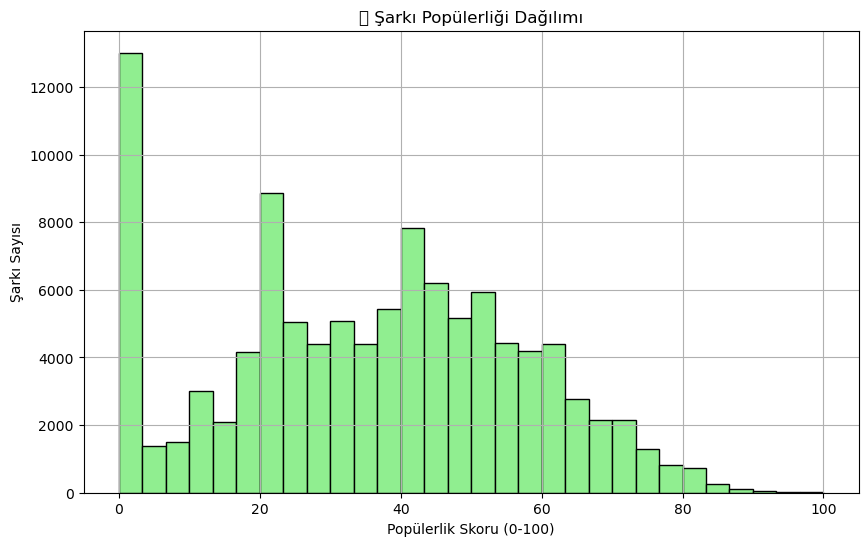

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['popularity'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('🎵 Şarkı Popülerliği Dağılımı')
plt.xlabel('Popülerlik Skoru (0-100)')
plt.ylabel('Şarkı Sayısı')
plt.grid(True)
plt.show()

C:\Users\T7\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128131 (\N{DANCER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\T7\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


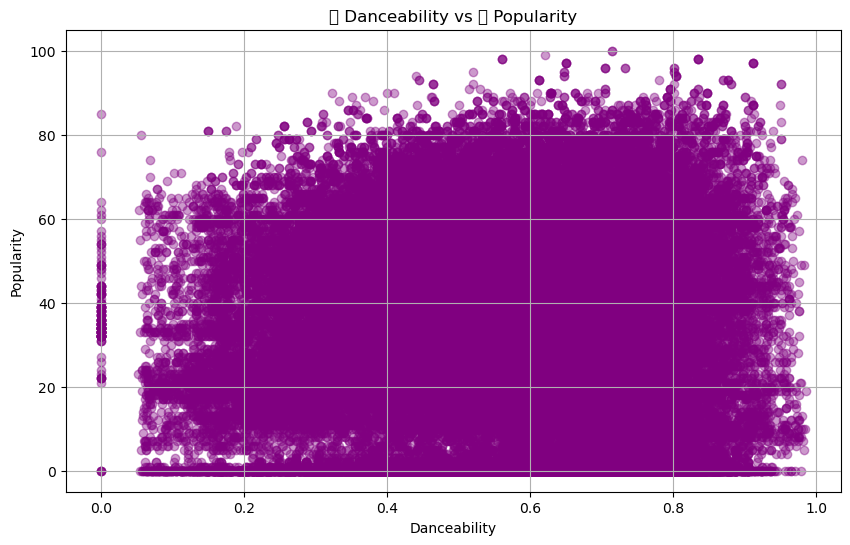

In [105]:
plt.figure(figsize=(10, 6))
plt.scatter(df['danceability'], df['popularity'], alpha=0.4, color='purple')
plt.title('💃 Danceability vs 🔥 Popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.grid(True)
plt.show()

In [107]:
correlation = df['danceability'].corr(df['popularity'])
print("Danceability vs Popularity Korelasyonu:", correlation)

Danceability vs Popularity Korelasyonu: 0.056829772541991674


In [109]:
# Girdi ve çıktı (bağımsız ve bağımlı değişkenler)
X = df[['danceability']]   # Girdi: Danceability
y = df['popularity']       # Çıktı: Popularity

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [115]:
y_pred = model.predict(X_test)

# Hata hesapla
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Ortalama Hata (MSE):", mse)
print("Açıklanan Varyans (R2):", r2)


Ortalama Hata (MSE): 452.77022868401053
Açıklanan Varyans (R2): 0.004272532578262878


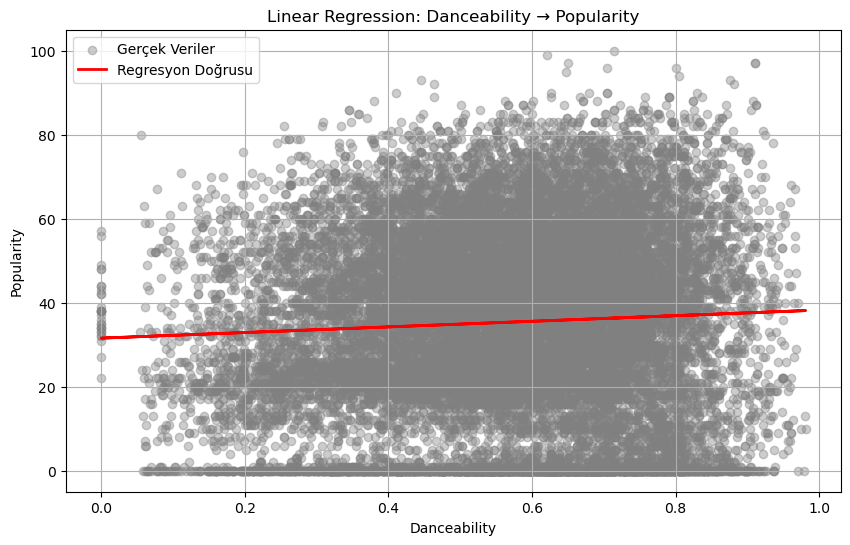

In [117]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='gray', alpha=0.4, label='Gerçek Veriler')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresyon Doğrusu')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Linear Regression: Danceability → Popularity')
plt.legend()
plt.grid(True)
plt.show()

In [119]:
features = ['danceability', 'energy', 'acousticness', 'valence', 'tempo']
X = df[features]
y = df['popularity']

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [125]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Ortalama Hata (MSE):", mse)
print("Açıklanan Varyans (R2):", r2)

Ortalama Hata (MSE): 451.4333108775015
Açıklanan Varyans (R2): 0.007212667987552934


In [127]:
coeff_df = pd.DataFrame(model.coef_, index=features, columns=['Katsayı'])
print(coeff_df)

               Katsayı
danceability  9.394474
energy       -2.930043
acousticness -2.499241
valence      -4.054602
tempo         0.008498
